100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.80MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 101kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 457kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.60MB/s]


Epoch [1/5], Loss: 0.0165
Epoch [2/5], Loss: 0.0090
Epoch [3/5], Loss: 0.0086
Epoch [4/5], Loss: 0.0083
Epoch [5/5], Loss: 0.0082


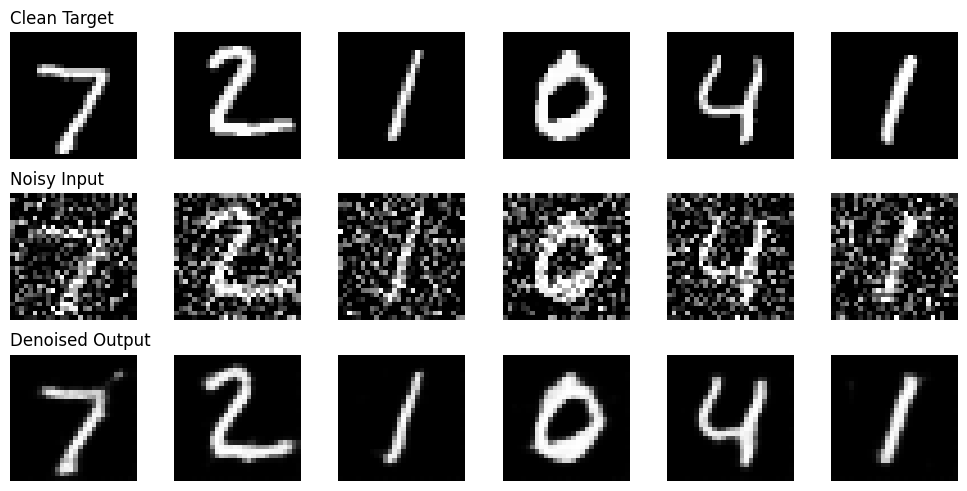

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Helper function to add Gaussian noise
def add_noise(images, noise_factor=0.4):
    noisy_images = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy_images, 0.0, 1.0)

# 3. Model Architecture
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder: (1, 28, 28) -> (32, 14, 14) -> (64, 7, 7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True)
        )
        
        # Decoder: (64, 7, 7) -> (32, 14, 14) -> (1, 28, 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Restrict pixel values between [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 4. Training
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    for clean_imgs, _ in train_loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_noise(clean_imgs).to(device)
        
        # Forward pass: reconstruct clean images from noisy inputs
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        
        # Backward & Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * clean_imgs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# 5. Visualizing Denoising Results
model.eval()
with torch.no_grad():
    clean_sample, _ = next(iter(test_loader))
    clean_sample = clean_sample.to(device)
    noisy_sample = add_noise(clean_sample).to(device)
    denoised_sample = model(noisy_sample).cpu()

# Plot first 6 samples: Clean, Noisy, Reconstructed
n_samples = 6
fig, axes = plt.subplots(3, n_samples, figsize=(10, 5))
for i in range(n_samples):
    axes[0, i].imshow(clean_sample[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Clean Target', loc='left')
    
    axes[1, i].imshow(noisy_sample[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Noisy Input', loc='left')
    
    axes[2, i].imshow(denoised_sample[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title('Denoised Output', loc='left')

plt.tight_layout()
plt.show()